In [ ]:
!pip install pymoo==0.6.0
!pip show pymoo


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Name: pymoo
Version: 0.6.0
Summary: Multi-Objective Optimization in Python
Home-page: https://pymoo.org
Author: Julian Blank
Author-email: blankjul@msu.edu
License: Apache License 2.0
Location: c:\users\krasi\appdata\local\programs\python\python310\lib\site-packages
Requires: alive-progress, autograd, cma, Deprecated, dill, matplotlib, numpy, scipy
Required-by: 


In [ ]:
import numpy as np
import random
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# -------------------------
# Data setup
# -------------------------

# Parameters
max_Capacity = 96  # Not restrictive here
delta_w = 3 # Max allowed weight difference for stacking heavier container

random.seed(42)
np.random.seed(42)

containers = [
    {"id": i, "weight": random.uniform(5, 20), "priority": random.randint(1, 4)}
    for i in range(max_Capacity)
]

positions = [(b, r, t) for b in range(8) for r in range(4) for t in range(3)]
n_positions = len(positions)
n_containers = len(containers)
#print(f"# of Positions: {n_positions}")
#print(f"# of Containers: {n_containers}")

# -------------------------
# Problem Definition
# -------------------------
class ContainerPlacementProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=n_containers,
            n_obj=3,
            n_constr=3,
            xl=0,
            xu=n_positions - 1,
            type_var=np.int32
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        G = []

        for x in X:
            assigned_positions = [positions[int(i)] for i in x]

            pos_counter = {}
            unique_assignment_violation = 0
            structure_violations = 0
            weight_stack_violations = 0
            violations = 0

            # One container per cell constraint
            for pos_index in x:
                pos_counter[pos_index] = pos_counter.get(pos_index, 0) + 1
            for v in pos_counter.values():
                if v > 1:
                    unique_assignment_violation += (v - 1)

            # Unloading order violations
            for i, c1 in enumerate(containers):
                for j, c2 in enumerate(containers):
                    if c1["priority"] > c2["priority"]:
                        b1, r1, t1 = assigned_positions[i]
                        b2, r2, t2 = assigned_positions[j]
                        if b1 == b2 and r1 == r2 and t1 > t2:
                            violations += 1

            # Stacking structure and weight delta
            for i, (b1, r1, t1) in enumerate(assigned_positions):
                for j, (b2, r2, t2) in enumerate(assigned_positions):
                    if b1 == b2 and r1 == r2:
                        if t1 == t2 + 1:
                            w1 = containers[i]['weight']
                            w2 = containers[j]['weight']
                            if w1 - w2 > delta_w:
                                weight_stack_violations += 1
                        if t1 > 0:
                            below = (b1, r1, t1 - 1)
                            if below not in assigned_positions:
                                structure_violations += 1

            # Center of gravity objective
            x_centroid = (max(b for b, r, t in positions) + 1) / 2
            y_centroid = (max(r for b, r, t in positions) + 1) / 2
            total_weight = 0
            x_moment = 0
            y_moment = 0
            for i, cont in enumerate(containers):
                b, r, _ = assigned_positions[i]
                w = cont["weight"]
                x_moment += b * w
                y_moment += r * w
                total_weight += w
            deviation = 1000.0 if total_weight == 0 else (
                abs(x_moment / total_weight - x_centroid) + abs(y_moment / total_weight - y_centroid)
            )

            used_count = len(set(x))

            # Objectives
            F.append([
                violations,     # minimize unloading violations
                deviation,      # minimize centroid deviation
                -used_count     # maximize usage
            ])

            # Constraints — each >= 0 means a violation
            G.append([
                unique_assignment_violation,
                structure_violations,
                weight_stack_violations
            ])

        out["F"] = np.array(F)
        out["G"] = np.array(G)



# -------------------------
# Main
# -------------------------
problem = ContainerPlacementProblem()

algorithm = NSGA2(
    pop_size=100,
    sampling=IntegerRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 100)

res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    save_history=True,
    verbose=True
)

# -------------------------
# Results
# -------------------------
print("\n--- Pareto-optimal Solutions (first 5) ---")
for i in range(min(5, len(res.F))):
    print(f"Solution {i+1}: Objectives = {res.F[i]}, Assignment = {res.X[i]}")


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  7.900000E+01 |  1.269000E+02 |             - |             -
     2 |      200 |      1 |  7.000000E+01 |  1.057600E+02 |             - |             -
     3 |      300 |      1 |  4.500000E+01 |  8.587000E+01 |             - |             -
     4 |      400 |      1 |  4.500000E+01 |  7.111000E+01 |             - |             -
     5 |      500 |      1 |  3.600000E+01 |  6.419000E+01 |             - |             -
     6 |      600 |      1 |  3.600000E+01 |  5.937000E+01 |             - |             -
     7 |      700 |      1 |  3.500000E+01 |  5.599000E+01 |             - |             -
     8 |      800 |      1 |  3.500000E+01 |  5.182000E+01 |             - |             -
     9 |      900 |      1 |  3.300000E+01 |  4.913000E+01 |             - |             -
    10 |     1000 |      1 |  3.300000E+01 |  4.631000E+01 |             - |             -

In [ ]:
best_by_count = max(res.F, key=lambda f: f[2])  # Maximize -used_count
print("\nBest solution by container count:", -best_by_count[2])


Best solution by container count: 96.0


In [ ]:
print("\n--- Top 5 Solutions (Most Containers Used) ---")
top_by_count = sorted(zip(res.F, res.X), key=lambda x: -x[0][2])[:5]
for i, (obj, sol) in enumerate(top_by_count):
    print(f"#{i+1}: Containers Used={-obj[2]}, Viol+Penalty={obj[0]}, CoG Deviation={obj[1]:.3f}, Assignment={sol}")


--- Top 5 Solutions (Most Containers Used) ---
#1: Containers Used=96.0, Viol+Penalty=29.0, CoG Deviation=0.647, Assignment=[81.96589456  6.95558941 34.6141217  23.41398792 67.13496488 93.28477768
 58.52661841 22.01591176 34.19318702  6.28801949 22.43675585 69.2395352
 57.83207465 30.40331169 70.45753875 75.72902675 87.9566701  68.2985715
 69.33599072 28.52449892  0.55706683 32.00943919 93.66884636 57.27613831
 19.68800376 25.41655115 23.6635891  52.93537228 92.31452024 21.74706587
 78.39142865 63.51705121 57.70153591 72.14804118 32.89357423 33.04397626
 78.43696177 32.05645255 15.81634692 94.38248742 91.37354434 85.86748485
 12.66999934 67.91280177 18.49176971 48.78792044 92.30093505 42.90142257
  7.86455244 66.26818845 25.07616514 27.41232863 52.56453677 52.7739154
 54.11832534 60.11846888 61.73985077 92.66422704 31.66793885 51.7216839
 54.05849342 18.71790308 84.59291229 33.64887734 20.70608172 57.95364043
 92.82510324 69.14236191 79.23812156 33.2263307  44.56190733 66.77195086
 88

# Pareto Front

In [ ]:
import matplotlib.pyplot as plt
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


--- Pareto Front Solutions ---
#1: Containers Used = 96.0, Violations = 29.0, CoG Deviation = 0.647
#2: Containers Used = 96.0, Violations = 15.0, CoG Deviation = 0.753
#3: Containers Used = 96.0, Violations = 30.0, CoG Deviation = 0.640
#4: Containers Used = 96.0, Violations = 19.0, CoG Deviation = 0.700
#5: Containers Used = 96.0, Violations = 17.0, CoG Deviation = 0.715
#6: Containers Used = 96.0, Violations = 21.0, CoG Deviation = 0.685
#7: Containers Used = 96.0, Violations = 13.0, CoG Deviation = 0.826
#8: Containers Used = 96.0, Violations = 27.0, CoG Deviation = 0.669
#9: Containers Used = 96.0, Violations = 18.0, CoG Deviation = 0.704
#10: Containers Used = 96.0, Violations = 14.0, CoG Deviation = 0.797
#11: Containers Used = 96.0, Violations = 21.0, CoG Deviation = 0.685
#12: Containers Used = 96.0, Violations = 28.0, CoG Deviation = 0.663
#13: Containers Used = 96.0, Violations = 12.0, CoG Deviation = 0.844
#14: Containers Used = 96.0, Violations = 16.0, CoG Deviation = 0.7

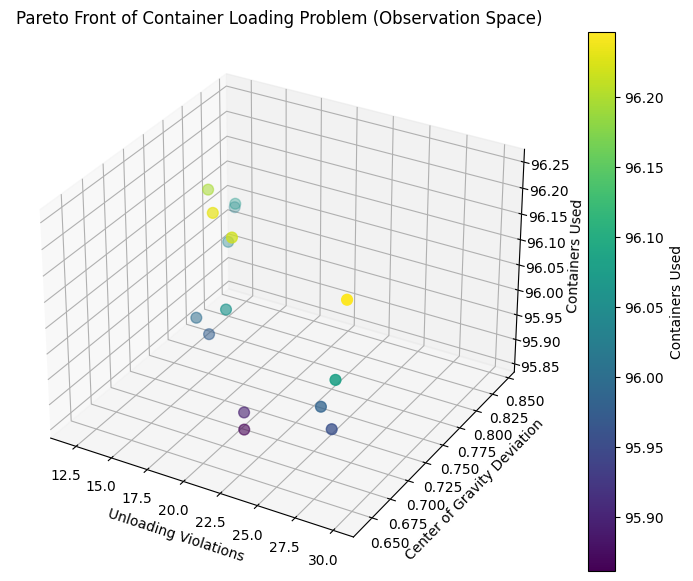

In [ ]:
# Extract Pareto front
F = np.array(res.F)

# Perform non-dominated sorting
nds = NonDominatedSorting()
pareto_indices = nds.do(F, only_non_dominated_front=True)

pareto_front = F[pareto_indices]
pareto_solutions = [res.X[i] for i in pareto_indices]

#print(f"Total number of Pareto front solutions: {len(pareto_front)}")
#print(f"Total number of solutions: {len(F)}")
#print(f"Deviation: {deviation}")
#print(f"Used: {used}")

# Print Pareto-optimal Solutions
print("\n--- Pareto Front Solutions ---")
for i, (obj, sol) in enumerate(zip(pareto_front, pareto_solutions)):
    print(f"#{i+1}: Containers Used = {-obj[2]}, Violations = {obj[0]}, CoG Deviation = {obj[1]:.3f}")

# 3D Plot of Pareto Front
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Extract objectives
viol = pareto_front[:, 0]    # Unloading Violations
deviation = pareto_front[:, 1]  # CoG Deviation
used = -pareto_front[:, 2]  # Containers Used (flip back since we minimized negative)

# Add jitter to the 'Used' values to avoid overlapping points (since all 'Used' values are 96)
jitter = np.random.normal(scale=0.1, size=used.shape)  # Small random noise
used_jittered = used + jitter

# Create the scatter plot with jittered 'Used' values
sc = ax.scatter(viol, deviation, used_jittered, c=used_jittered, cmap='viridis', s=60)

# Labeling the axes
ax.set_xlabel("Unloading Violations")
ax.set_ylabel("Center of Gravity Deviation")
ax.set_zlabel("Containers Used")
ax.set_title("Pareto Front of Container Loading Problem (Observation Space)")

# Add a color bar to indicate the number of containers used
plt.colorbar(sc, label="Containers Used")

# Show the plot
plt.show()

# Efficient Set

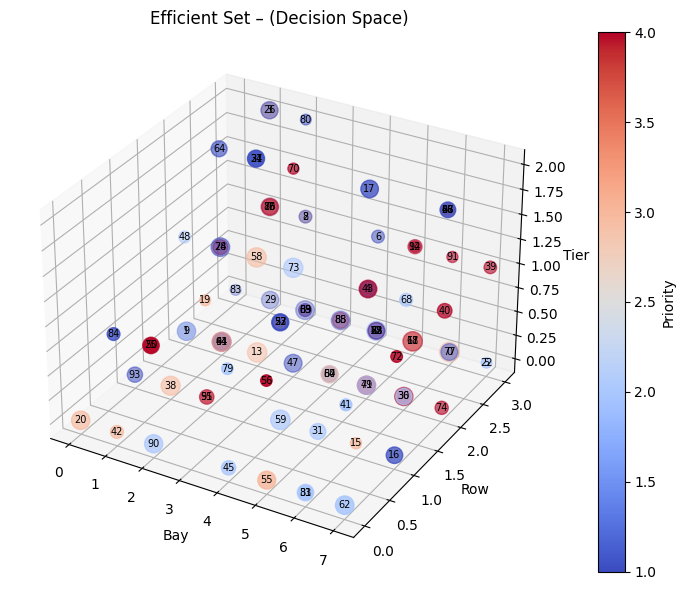

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Get the best Pareto solution (first one in the sorted Pareto front)
best_solution = pareto_solutions[0]

# Extract position info for the best solution
xs, ys, zs = [], [], []
weights = []
priorities = []

for i, pos_index in enumerate(best_solution):
    b, r, t = positions[int(pos_index)]
    xs.append(b)
    ys.append(r)
    zs.append(t)
    weights.append(containers[i]["weight"])
    priorities.append(containers[i]["priority"])

# Plot the efficient set (container placements)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Color by priority, size by weight
sc = ax.scatter(xs, ys, zs, c=priorities, cmap='coolwarm', s=[w * 10 for w in weights])

# Annotate each point with container ID
for i, (b, r, t) in enumerate(zip(xs, ys, zs)):
    ax.text(b, r, t, str(i), fontsize=7, ha='center', va='center')

# Labels and title
ax.set_title("Efficient Set – (Decision Space)")
ax.set_xlabel("Bay")
ax.set_ylabel("Row")
ax.set_zlabel("Tier")

plt.colorbar(sc, label="Priority")
plt.tight_layout()
plt.show()

In [ ]:

"""
from mpl_toolkits.mplot3d import Axes3D

# Visualize the first 3 Pareto-optimal container placements
num_to_plot = 3
figsize = (12, 5)

for idx in range(min(num_to_plot, len(pareto_solutions))):
    solution = pareto_solutions[idx]
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    xs, ys, zs = [], [], []
    weights = []
    priorities = []

    for i, pos_index in enumerate(solution):
        b, r, t = positions[int(pos_index)]
        xs.append(b)
        ys.append(r)
        zs.append(t)
        weights.append(containers[i]["weight"])
        priorities.append(containers[i]["priority"])

    sc = ax.scatter(xs, ys, zs, c=priorities, cmap='coolwarm', s=[w * 10 for w in weights])
    ax.set_title(f"Efficient Solution #{idx+1}")
    ax.set_xlabel("Bay")
    ax.set_ylabel("Row")
    ax.set_zlabel("Tier")
    plt.colorbar(sc, label="Priority")
    plt.show()
    """


'\nfrom mpl_toolkits.mplot3d import Axes3D\n\n# Visualize the first 3 Pareto-optimal container placements\nnum_to_plot = 3\nfigsize = (12, 5)\n\nfor idx in range(min(num_to_plot, len(pareto_solutions))):\n    solution = pareto_solutions[idx]\n    fig = plt.figure(figsize=figsize)\n    ax = fig.add_subplot(111, projection=\'3d\')\n\n    xs, ys, zs = [], [], []\n    weights = []\n    priorities = []\n\n    for i, pos_index in enumerate(solution):\n        b, r, t = positions[int(pos_index)]\n        xs.append(b)\n        ys.append(r)\n        zs.append(t)\n        weights.append(containers[i]["weight"])\n        priorities.append(containers[i]["priority"])\n\n    sc = ax.scatter(xs, ys, zs, c=priorities, cmap=\'coolwarm\', s=[w * 10 for w in weights])\n    ax.set_title(f"Efficient Solution #{idx+1}")\n    ax.set_xlabel("Bay")\n    ax.set_ylabel("Row")\n    ax.set_zlabel("Tier")\n    plt.colorbar(sc, label="Priority")\n    plt.show()\n    '